In [99]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk(r'..\dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

..\dataset\Student-Employability-Datasets.xlsx


In [100]:
df = pd.read_excel(r'..\dataset\Student-Employability-Datasets.xlsx')

df.head()

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable
4,Student 5,4,4,3,3,4,4,3,5,Employable


In [101]:
print('Missing values Percentage: \n\n', round (df.isnull().sum().sort_values(ascending=False)/len(df)*100,1))


Missing values Percentage: 

 Name of Student               0.0
GENERAL APPEARANCE            0.0
MANNER OF SPEAKING            0.0
PHYSICAL CONDITION            0.0
MENTAL ALERTNESS              0.0
SELF-CONFIDENCE               0.0
ABILITY TO PRESENT IDEAS      0.0
COMMUNICATION SKILLS          0.0
Student Performance Rating    0.0
CLASS                         0.0
dtype: float64


In [102]:
def columnCategory(dataset, categoryTotal=20):
    """
    Displays an orderly breakdown of every column. 
    Lists specific values for low cardinality columns, and flags 
    high cardinality columns without flooding the screen.
    """
    print(f"=== DATAFRAME CARDINALITY & CATEGORY ANALYSIS ===")
    print(f" Threshold for Low Cardinality: <= {categoryTotal} unique values\n")
    print("=" * 60)
    
    for column in dataset.columns:
        # Get unique values and ignore null values for an accurate count
        unique_vals = dataset[column].dropna().unique()
        unique_count = len(unique_vals)
        
        print(f"📌 Column: {column}")
        print(f"   • Total Unique Values: {unique_count}")
        
        # Condition A: Low Cardinality (Categorical)
        if unique_count <= categoryTotal:
            print(f"   • Status: [ LOW CARDINALITY / CATEGORY ]")
            # Sort the unique values for an orderly display
            try:
                sorted_vals = sorted(unique_vals)
            except TypeError:
                sorted_vals = sorted(unique_vals, key=str)
                
            print(f"   • Categories: {sorted_vals}")
            
        # Condition B: High Cardinality
        else:
            print(f"   • Status: [ HIGH CARDINALITY ]")
            print(f"   • Note: Exceeds threshold. Likely an ID, Name, or continuous numeric column.")
            
        print("-" * 60)

columnCategory(df)

=== DATAFRAME CARDINALITY & CATEGORY ANALYSIS ===
 Threshold for Low Cardinality: <= 20 unique values

📌 Column: Name of Student
   • Total Unique Values: 2982
   • Status: [ HIGH CARDINALITY ]
   • Note: Exceeds threshold. Likely an ID, Name, or continuous numeric column.
------------------------------------------------------------
📌 Column: GENERAL APPEARANCE
   • Total Unique Values: 4
   • Status: [ LOW CARDINALITY / CATEGORY ]
   • Categories: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
------------------------------------------------------------
📌 Column: MANNER OF SPEAKING
   • Total Unique Values: 4
   • Status: [ LOW CARDINALITY / CATEGORY ]
   • Categories: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
------------------------------------------------------------
📌 Column: PHYSICAL CONDITION
   • Total Unique Values: 4
   • Status: [ LOW CARDINALITY / CATEGORY ]
   • Categories: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
------------------------------

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Name of Student             2982 non-null   object
 1   GENERAL APPEARANCE          2982 non-null   int64 
 2   MANNER OF SPEAKING          2982 non-null   int64 
 3   PHYSICAL CONDITION          2982 non-null   int64 
 4   MENTAL ALERTNESS            2982 non-null   int64 
 5   SELF-CONFIDENCE             2982 non-null   int64 
 6   ABILITY TO PRESENT IDEAS    2982 non-null   int64 
 7   COMMUNICATION SKILLS        2982 non-null   int64 
 8   Student Performance Rating  2982 non-null   int64 
 9   CLASS                       2982 non-null   object
dtypes: int64(8), object(2)
memory usage: 233.1+ KB


Lets check if the data is skewed, inflated or supressed. 

In [104]:
df.describe()

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating
count,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000
mean,4.246814,3.884641,3.972166,3.962777,3.910798,3.813883,3.525486,4.610664
std,0.678501,0.757013,0.744135,0.781982,0.807602,0.739390,0.743881,0.692845
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [105]:
df.columns

Index(['Name of Student', 'GENERAL APPEARANCE', 'MANNER OF SPEAKING',
       'PHYSICAL CONDITION', 'MENTAL ALERTNESS', 'SELF-CONFIDENCE',
       'ABILITY TO PRESENT IDEAS', 'COMMUNICATION SKILLS',
       'Student Performance Rating', 'CLASS'],
      dtype='object')

In [106]:
rename = {
    'Name of Student': 'name_of_student',
    'GENERAL APPEARANCE': 'general_appearance',
    'MANNER OF SPEAKING': 'manner_of_speaking',
    'PHYSICAL CONDITION': 'physical_condition',
    'MENTAL ALERTNESS': 'mental_alertness',
    'SELF-CONFIDENCE': 'self_confidence',
    'ABILITY TO PRESENT IDEAS': 'ability_to_present_ideas',
    'COMMUNICATION SKILLS': 'communication_skills',
    'Student Performance Rating': 'student_performance_rating',
    'CLASS': 'class_label'
}

df.rename(columns=rename, inplace=True)


df.sample(5, random_state=0)

,name_of_student,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,communication_skills,student_performance_rating,class_label
316,Student 317,3,3,4,4,4,3,3,4,LessEmployable
2349,Student 2368,4,4,4,4,4,4,3,5,Employable
2549,Student 2568,4,3,3,4,5,4,3,5,LessEmployable
891,Student 892,4,3,4,2,2,2,2,5,LessEmployable
1284,Student 1285,5,5,5,5,5,5,4,5,LessEmployable


In [107]:
df["class_label"] = df["class_label"].map({
    'LessEmployable': 0,
    'Employable': 1
})


df.sample(5, random_state=0)

,name_of_student,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,communication_skills,student_performance_rating,class_label
316,Student 317,3,3,4,4,4,3,3,4,0
2349,Student 2368,4,4,4,4,4,4,3,5,1
2549,Student 2568,4,3,3,4,5,4,3,5,0
891,Student 892,4,3,4,2,2,2,2,5,0
1284,Student 1285,5,5,5,5,5,5,4,5,0


In [108]:
df = df.drop("name_of_student", axis=1)

df.sample(5, random_state=0)

,general_appearance,manner_of_speaking,physical_condition,mental_alertness,self_confidence,ability_to_present_ideas,communication_skills,student_performance_rating,class_label
316,3,3,4,4,4,3,3,4,0
2349,4,4,4,4,4,4,3,5,1
2549,4,3,3,4,5,4,3,5,0
891,4,3,4,2,2,2,2,5,0
1284,5,5,5,5,5,5,4,5,0


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   general_appearance          2982 non-null   int64
 1   manner_of_speaking          2982 non-null   int64
 2   physical_condition          2982 non-null   int64
 3   mental_alertness            2982 non-null   int64
 4   self_confidence             2982 non-null   int64
 5   ability_to_present_ideas    2982 non-null   int64
 6   communication_skills        2982 non-null   int64
 7   student_performance_rating  2982 non-null   int64
 8   class_label                 2982 non-null   int64
dtypes: int64(9)
memory usage: 209.8 KB


# training the Model 

In [110]:
# select the feature and the target
y = df.class_label
Xdf = df.drop(['class_label'], axis=1)


In [111]:
# lets split the data first
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    Xdf, y, test_size=0.2, train_size=0.8, random_state=0
)



In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=0, 
                                  n_estimators=500,
                                max_depth=None,
                                min_samples_split=2)
rf_model.fit(X_train, y_train,)



,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

predictions = rf_model.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, predictions))
print("Precision:", precision_score(y_valid, predictions, pos_label=1))
print("Recall:", recall_score(y_valid, predictions, pos_label=1))
print("F1-score:", f1_score(y_valid, predictions, pos_label=1))

# Or a full report



Accuracy: 0.9011725293132329
Precision: 0.9173789173789174
Recall: 0.9147727272727273
F1-score: 0.9160739687055477
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       245
           1       0.92      0.91      0.92       352

    accuracy                           0.90       597
   macro avg       0.90      0.90      0.90       597
weighted avg       0.90      0.90      0.90       597



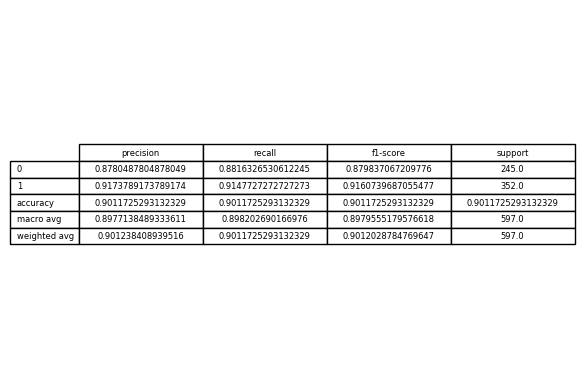

In [132]:
import matplotlib.pyplot as plt
report = classification_report(y_valid, predictions, output_dict=True) # output dict turns the data into a dictionary 
reported = pd.DataFrame(report).T # use .T to transpose.
reported


fig, ax = plt.subplots()
ax.axis("off")
pd.plotting.table(ax, reported, loc="center", cellLoc="center")



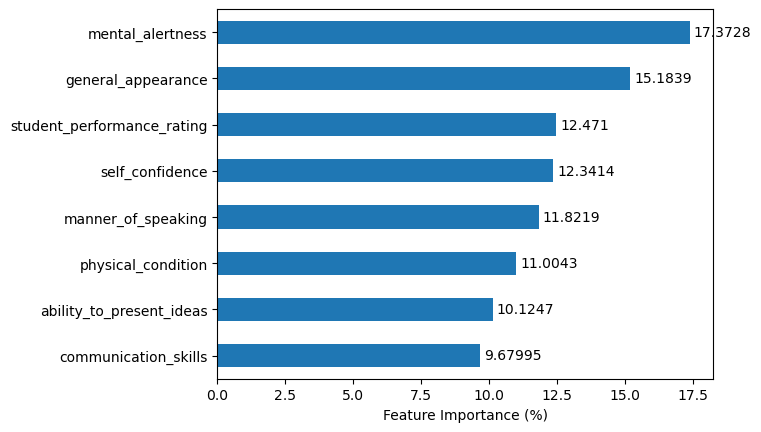

In [ ]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns) * 100 # gets the values and into a seriesFrame
fig, ax = plt.subplots() # gets the figures and the axis 

feat_imp.sort_values().plot(kind='barh', ax=ax) # sorts the values first and then plots them via barh and then gets teh axis of the subplot

ax.bar_label(ax.containers[0], padding=3, ) # puts the value of each feature at the end of the bars 

plt.xlabel("Feature Importance (%)")
plt.show()


In [116]:
feat_imp.head()

general_appearance    15.183902
manner_of_speaking    11.821938
physical_condition    11.004259
mental_alertness      17.372771
self_confidence       12.341427
dtype: float64

# Result Discussion. overall importances
- We see that the overall accurary of the model is 90 percent. with a precision of 91 percent, a recall of 91 percent and an F1 of 91.6 percent. 

- we see that Mental Alertness and General Apperance weighs heavy. which accounts to 17.37 and 15.18 percent when it comes to making a choice whether someones is employable or less employable. this shows that mental alertness there is a wide gap in importnace compared to communication skills (9.7). 

In [121]:
df.to_csv(r"..\score\SEdataset.csv", index=False)
feat_imp.to_csv(r"..\score\Featureimportance.csv", index=True)